In [5]:
import uproot
import pandas as pd
import numpy as np
import glob


In [6]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.style.use('belle2')

import os

In [22]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13_all/proc13_all_etapip_loose_v7_250205_Dp_dz"
base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13_all/proc13_all_etapip_loose_v7_250216_CMS_Psum"

# base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_etaetapip_loose_v7_250122_temp"
# cm_elements = ["etahp_13_had_4S_off_v1", "etahp_13_had_4S_v3", "etahp_23_had_4S_off_v1", "etahp_23_had_4S_v1", "etahp_23_had_5Sscan_10657_v1", "etahp_23_had_5Sscan_10706_v1",\
               # "etahp_23_had_5Sscan_10751_v1", "etahp_23_had_5Sscan_10810_v1"]
cm_elements = ["etahp_13_4S_off_v1", "etahp_13_4S_v2", "etahp_23_4S_off_v1", "etahp_23_4S_v1", "etahp_23_5Sscan_10657_v1", "etahp_23_5Sscan_10706_v1",\
               "etahp_23_5Sscan_10751_v1", "etahp_23_5Sscan_10810_v1"]
cut_expression = "Dp_M>0"
tree_name = "etapip_gg"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{tree_name}/new_FOM/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [23]:
df_proc13 = pd.concat(dataframes, ignore_index=True)


In [24]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,544722.000000,544722.000000,544722.000000,544722.000000,544722.000000
mean,1.773842,0.076444,0.356015,1.546898,-0.002945
std,0.154271,0.494281,0.502156,0.872536,0.999997
min,1.500000,-0.999949,-0.898152,0.400001,-1.000000
25%,1.647671,-0.331887,-0.024125,0.790485,-1.000000
50%,1.756755,0.082611,0.489779,1.409967,-1.000000
75%,1.908030,0.498512,0.799829,2.141573,1.000000
max,2.099992,0.999976,0.976842,5.712657,1.000000


In [25]:
df_proc13 = df_proc13.query('Dp_M> 1.7 & Dp_M<2.1')


In [26]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,342504.000000,342504.000000,342504.000000,342504.000000,342504.000000
mean,1.870056,0.073674,0.363036,1.573161,-0.003095
std,0.104756,0.494868,0.502478,0.899338,0.999997
min,1.700001,-0.999949,-0.886036,0.400002,-1.000000
25%,1.771259,-0.334149,-0.017494,0.793912,-1.000000
50%,1.869618,0.077696,0.501913,1.431917,-1.000000
75%,1.962794,0.493985,0.806809,2.179840,1.000000
max,2.099992,0.999976,0.974742,5.712657,1.000000


In [27]:
nan_columns = df_proc13.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [28]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_true_Dp_CMS_p"
# base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_noD0"

cm_elements = ["15rd_eta_e7_18_4S_v3", "15rd_eta_e20_b26_v1", "15rd_eta_e20_e26_4S_v2", "15rd_eta_e21_5S_scan_v1", "15rd_eta_mori_off_v1"]

cut_expression = "Dp_M>0"
tree_name = "etapip_gg"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    # pattern = f"{base_path}/{element}/{tree_name}/*.BCS.root"
    pattern = f"{base_path}/{element}/{tree_name}/train_Dp_dz/skimhad/new_FOM/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [29]:
df_mc15rd = pd.concat(dataframes, ignore_index=True)


In [30]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,1.759426e+06,1.759426e+06,1.759426e+06,1.759426e+06,1.759426e+06
mean,1.768396e+00,5.999543e-02,3.166557e-01,1.592870e+00,-3.820564e-03
std,1.529580e-01,4.994782e-01,4.935775e-01,8.375403e-01,9.999930e-01
min,1.500000e+00,-9.999442e-01,-8.998164e-01,4.000002e-01,-1.000000e+00
25%,1.643144e+00,-3.566865e-01,-6.710942e-02,8.889451e-01,-1.000000e+00
50%,1.748389e+00,6.253933e-02,4.188689e-01,1.483224e+00,-1.000000e+00
75%,1.905972e+00,4.876572e-01,7.522932e-01,2.153350e+00,1.000000e+00
max,2.099998e+00,9.999881e-01,9.736712e-01,5.641366e+00,1.000000e+00


In [31]:
df_mc15rd = df_mc15rd.query('Dp_M> 1.7 & Dp_M<2.1')


In [32]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,1.078641e+06,1.078641e+06,1.078641e+06,1.078641e+06,1.078641e+06
mean,1.867649e+00,5.968822e-02,3.213367e-01,1.623225e+00,-3.555400e-03
std,1.031602e-01,4.997541e-01,4.935415e-01,8.602184e-01,9.999941e-01
min,1.700000e+00,-9.999442e-01,-8.951565e-01,4.000002e-01,-1.000000e+00
25%,1.768280e+00,-3.563786e-01,-6.306279e-02,9.028435e-01,-1.000000e+00
50%,1.869548e+00,6.120361e-02,4.266402e-01,1.511690e+00,-1.000000e+00
75%,1.963053e+00,4.858541e-01,7.577531e-01,2.193042e+00,1.000000e+00
max,2.099998e+00,9.999881e-01,9.736712e-01,5.641366e+00,1.000000e+00


In [33]:
nan_columns = df_mc15rd.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [34]:
from plothist import make_hist, plot_hist
from plothist import plot_two_hist_comparison, add_luminosity


In [35]:
tree_to_compare = "etapip_gg"
plt.rcParams['font.family'] = 'DejaVu Sans'


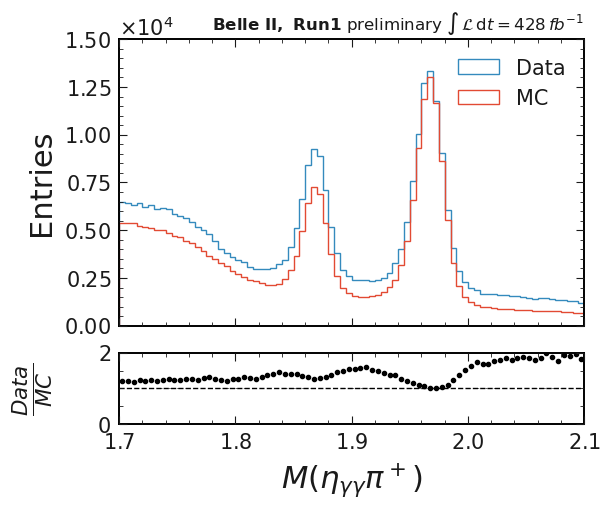

In [36]:
name = "Dp_M"
category = "category"
xlabel = r"$M(\eta_{\gamma\gamma} \pi^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (1.7,2.1)

h1 = make_hist(x1, bins=80, range=x_range, weights=1)
h2 = make_hist(x2, bins=80, range=x_range, weights=1/4)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{name}_skimhad_new_FOM.png", bbox_inches="tight")